In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from scipy.stats import pearsonr

Test Variables

In [11]:
dt = pd.read_csv("cleaned_case1.csv")
dt.columns

Index(['Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.1.1', 'Unnamed: 0.1.1.1',
       'METHODS:   Sampling/Analysis', 'Incubation Time (hour)',
       'DATE (yyyy-mm-dd)', 'LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Total N2 Fixation (μmol N m-3 d-1)', 'DATE_str', 'DATE', 'YRDY',
       'SST(m)', 'CHL(m)', 'PAR(m)', 'salinity', 'Nitrate', 'Phosphate',
       'dissolved_oxygen', 'Fe', 'Fe:N', 'N:P', 'coord1', 'coord2', 'coord3',
       'month', 'time_cos', 'time_sin', 'log_Fe', 'log_N', 'log_P', 'region',
       'group', 'group_code', 'log_y', 'log_CHL', 'T', 'MLD', 'Bathymetry'],
      dtype='object')

In [12]:
columns = ["Total N2 Fixation (μmol N m-3 d-1)",
            "MLD", "salinity", "dissolved_oxygen", "T", "SST(m)", 
                 "CHL(m)", "PAR(m)", "Nitrate"]
           
# every col and the range
for column in columns:  
    max_value = dt[column].max()
    min_value = dt[column].min()
    print(column)
    print(min_value)
    print(max_value)

Total N2 Fixation (μmol N m-3 d-1)
0.0001
29.897107
MLD
9.947540259533058
138.91298666235951
salinity
32.084
37.613
dissolved_oxygen
3.252
289.105
T
4.561
30.052
SST(m)
6.5
32.39
CHL(m)
0.007771009
6.227081
PAR(m)
4.719997
67.816
Nitrate
0.001
33.877


In [13]:
columns = ['Phosphate', "Fe", "DEPTH (m)", 
           "coord1", "coord2", "coord3", 
           "time_sin", "time_cos"]
           
# every col and the range
for column in columns:  
    max_value = dt[column].max()
    min_value = dt[column].min()
    print(column)
    print(min_value)
    print(max_value)

Phosphate
0.001
2.788
Fe
0.0662196329816368
1.1922764233060528
DEPTH (m)
0.0
4000.0
coord1
-0.737277336810124
0.7253743710122875
coord2
-0.9969348998479404
0.9993944760538476
coord3
-0.9999111419886556
0.9999999996845604
time_sin
-1.0
1.0
time_cos
-1.0
1.0


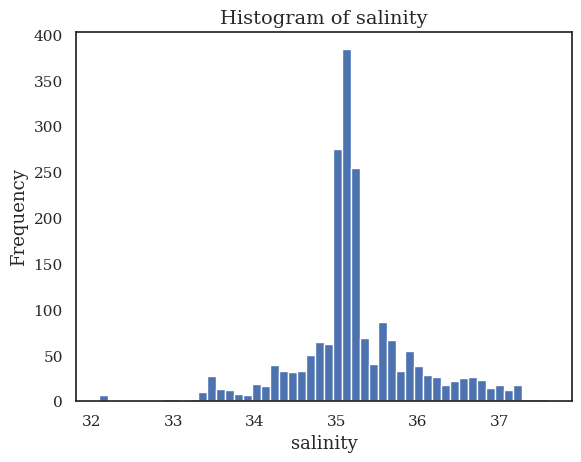

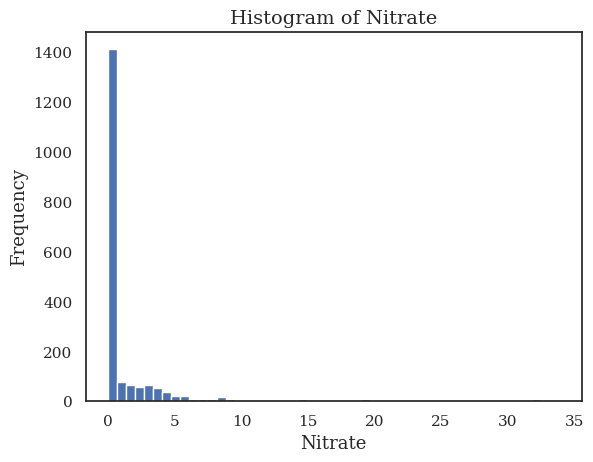

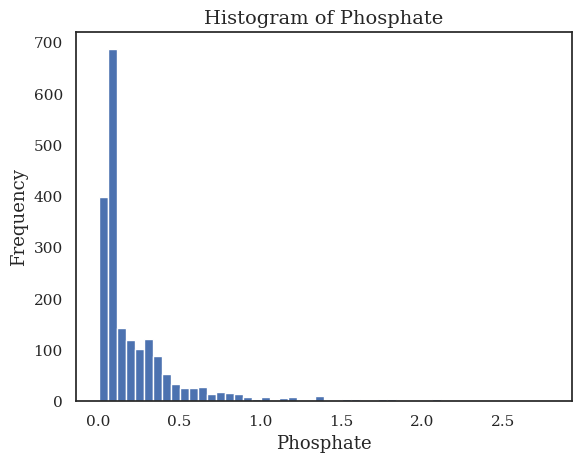

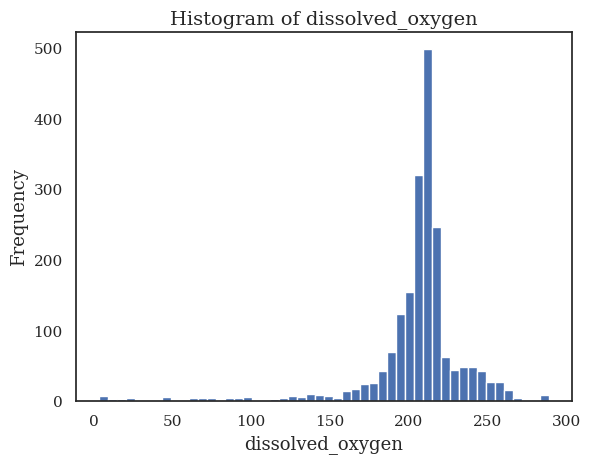

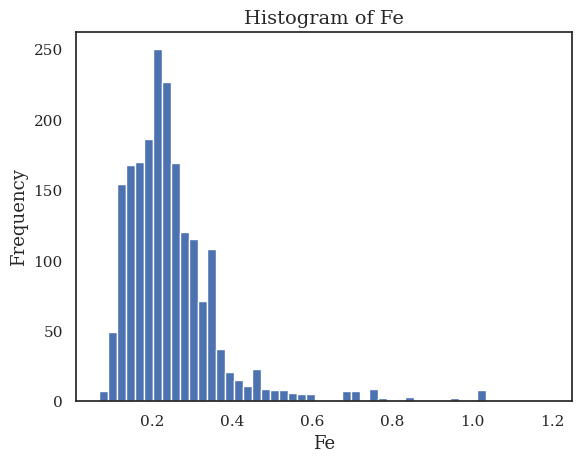

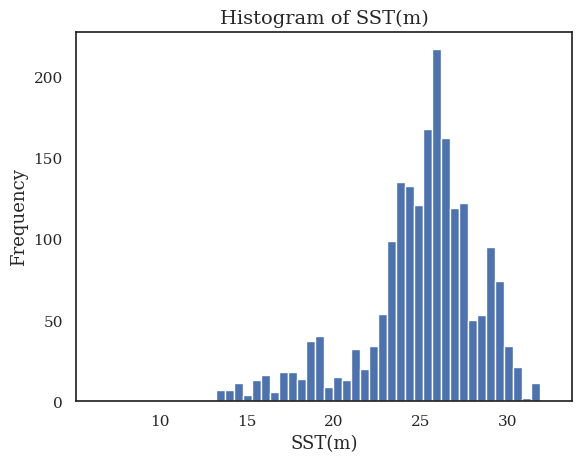

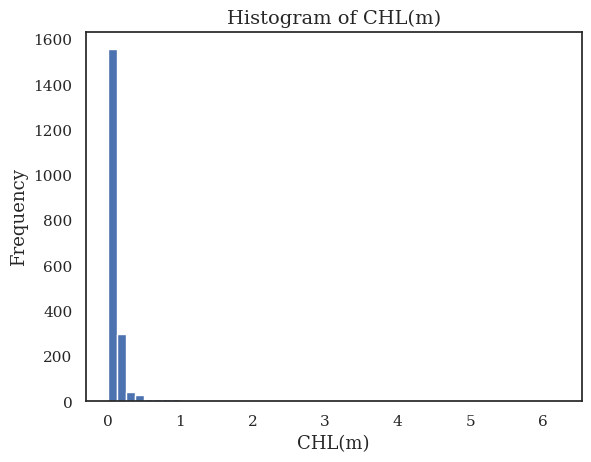

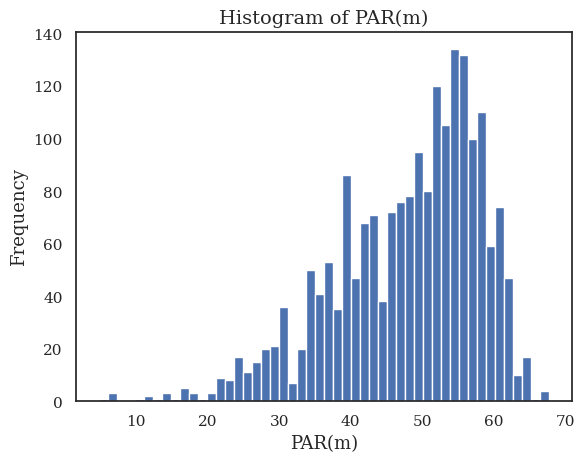

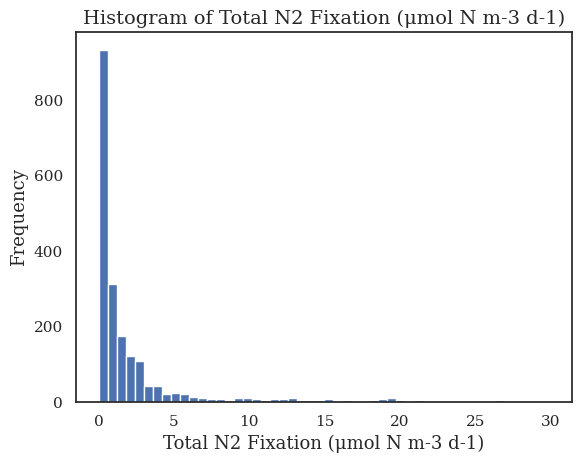

In [15]:
cols = [
    'salinity', 'Nitrate', 'Phosphate', 'dissolved_oxygen', 'Fe',
    'SST(m)', 'CHL(m)', 'PAR(m)',
    'Total N2 Fixation (μmol N m-3 d-1)'
]

# Convert to numeric safely
for c in cols:
    dt[c] = pd.to_numeric(dt[c], errors='coerce')

# Plot histogram
for c in cols:
    plt.figure()
    data = dt[c].dropna()
    plt.hist(data, bins=50)
    plt.title(f"Histogram of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

In [5]:
# not log10
predictors = ["MLD", "salinity", "dissolved_oxygen", "T", "SST(m)", 
                 "CHL(m)", "PAR(m)", "Nitrate", 'Phosphate', "Fe", "DEPTH (m)", 
                "coord1", "coord2", "coord3", "time_sin", "time_cos"]
target = "Total N2 Fixation (μmol N m-3 d-1)"

results = []

#  Pearson coeff
for predictor in predictors:
    corr, p_value = pearsonr(dt[predictor], dt[target])
    results.append({"Predictor": predictor, "Correlation": corr, "P_value": p_value})

# DataFrame
correlation_results = pd.DataFrame(results)

# sort
correlation_results = correlation_results.sort_values(by="Correlation", key=lambda x: abs(x), ascending=False).reset_index(drop=True)

print(correlation_results)

           Predictor  Correlation       P_value
0             coord3     0.147821  3.398345e-11
1            Nitrate    -0.143896  1.116473e-10
2                  T     0.141855  2.045563e-10
3          DEPTH (m)    -0.133254  2.390645e-09
4           time_cos    -0.120945  6.192823e-08
5             coord1    -0.114681  2.884086e-07
6           salinity    -0.109297  1.016095e-06
7   dissolved_oxygen     0.107493  1.529641e-06
8          Phosphate    -0.107335  1.584990e-06
9             PAR(m)    -0.069172  2.013288e-03
10            coord2     0.053907  1.614545e-02
11            CHL(m)     0.038554  8.545453e-02
12               MLD    -0.028279  2.072080e-01
13            SST(m)     0.017767  4.281538e-01
14                Fe    -0.016018  4.750229e-01
15          time_sin     0.008403  7.078845e-01


Data Distrib.

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import pandas as pd

# data
dt = pd.read_csv("cleaned_case1.csv")

# group → biome
biome_to_group = {
    'NPacGyre': 'group1', 'NPac': 'group1',
    'EqAtl': 'group2', 'SAtl': 'group2',
    'EqPac': 'group3',
    'SPacGyre': 'group4',
    'NAtl': 'group5', 'NAtlGyre': 'group5',
    'NInd': 'group6', 'SInd': 'group6'
}

# group → biomes 
from collections import defaultdict
group_to_biomes = defaultdict(set)
for biome, group in biome_to_group.items():
    group_to_biomes[group].add(biome)

# group → marker 
group_markers = {
    'group1': 'o',   # circle
    'group2': 's',   # square
    'group3': '^',   # triangle
    'group4': 'D',   # diamond
    'group5': 'P',   # plus (filled)
    'group6': 'X'    # X mark
}

In [7]:
from matplotlib.ticker import LogLocator
import seaborn as sns
sns.set(style='white', context='notebook')
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "STIX", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13
})

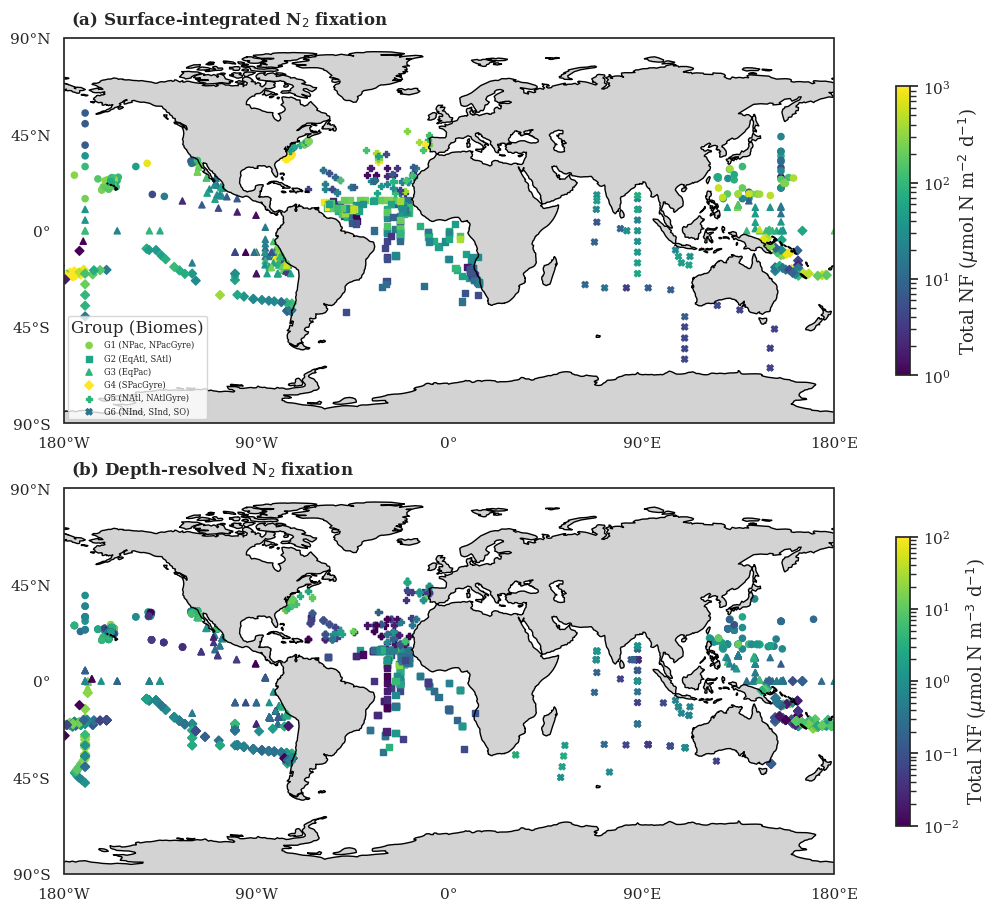

In [10]:
# ======================
# 1. Load data
# ======================
dt_depth = pd.read_csv("cleaned_case1.csv")
dt_surface = pd.read_csv("surface_data.csv")

# ======================
# 2. Group / marker definitions（保持不变）
# ======================
biome_to_group = {
    'NPacGyre': 'group1', 'NPac': 'group1',
    'EqAtl': 'group2', 'SAtl': 'group2',
    'EqPac': 'group3',
    'SPacGyre': 'group4',
    'NAtl': 'group5', 'NAtlGyre': 'group5',
    'NInd': 'group6', 'SInd': 'group6', 'SO':'group6'
}

group_markers = {
    'group1': 'o',
    'group2': 's',
    'group3': '^',
    'group4': 'D',
    'group5': 'P',
    'group6': 'X'
}

group_short = {
    'group1': 'G1',
    'group2': 'G2',
    'group3': 'G3',
    'group4': 'G4',
    'group5': 'G5',
    'group6': 'G6'
}

group_to_biomes = defaultdict(set)
for biome, group in biome_to_group.items():
    group_to_biomes[group].add(biome)

# ======================
# 3. Create figure (2 rows, 1 column)
# ======================
fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

datasets = [  (axes[0], dt_surface,
     "Total N2 Fixation (μmol N m-2 d-1)",
     r"Total NF ($\mu$mol N m$^{-2}$ d$^{-1}$)",
     "(a) Surface-integrated N$_2$ fixation",
     LogNorm(vmin=1, vmax=1000)),
    
    (axes[1], dt_depth,
     "Total N2 Fixation (μmol N m-3 d-1)",
     r"Total NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",
     "(b) Depth-resolved N$_2$ fixation",
     LogNorm(vmin=0.01, vmax=100))
]

# ======================
# 4. Plot loop
# ======================
for ax, data, varname, cbar_label, panel_label, norm in datasets:

    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_global()

    for group, marker in group_markers.items():
        subset = data[data["group"] == group]

        lat = subset["LATITUDE"].values
        lon = subset["LONGITUDE"].values
        fixation = subset[varname].values

        sc = ax.scatter(
            lon, lat,
            c=fixation,
            cmap="viridis",
            norm=norm,
            s=20,
            marker=marker,
            transform=ccrs.PlateCarree(),
            label=f"{group_short[group]} ({', '.join(sorted(group_to_biomes[group]))})"
        )

    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W', '90°W', '0°', '90°E', '180°E'])
    ax.set_yticklabels(['90°S', '45°S', '0°', '45°N', '90°N'])

    # panel label
    ax.text(
        0.01, 1.02, panel_label,
        transform=ax.transAxes,
        fontsize=12, fontweight="bold",
        ha="left", va="bottom"
    )

    # colorbar
    cbar = fig.colorbar(
        sc, ax=ax,
        orientation="vertical",
        fraction=0.035,
        pad=0.03,
        shrink=0.75
    )
    cbar.set_label(cbar_label, fontsize=13)
    cbar.ax.tick_params(labelsize=11)

# legend
axes[0].legend(
    loc='lower left',
    fontsize=6,
    title="Group (Biomes)",
    frameon=True
)
plt.show()
